In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 3*np.sin(x) + 4*x**2 + 7*x - 2 
def df(x):
    return 3*np.cos(x) + 8*x + 7

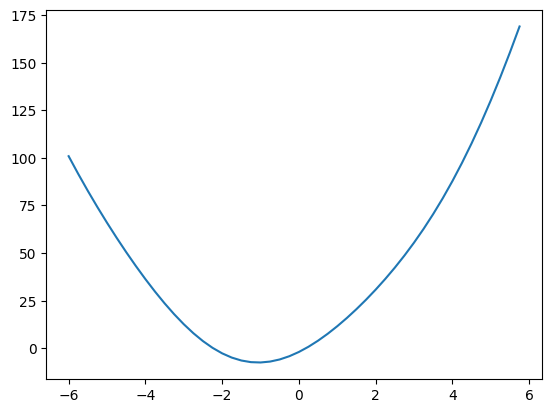

In [3]:
xs = np.arange(-6,6, 0.25)
ys = f(xs)
plt.plot(xs,ys)
dys1 = df(xs)

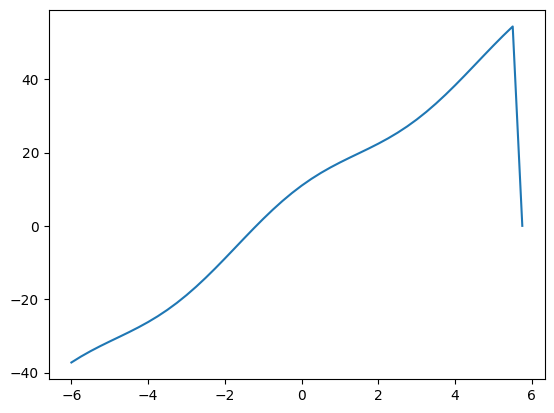

In [4]:
dys = np.zeros(len(xs))
for i in range(len(ys)-1):
    diff = ys[i+1]-ys[i]
    dys[i] = diff/0.25
plt.plot(xs,dys)

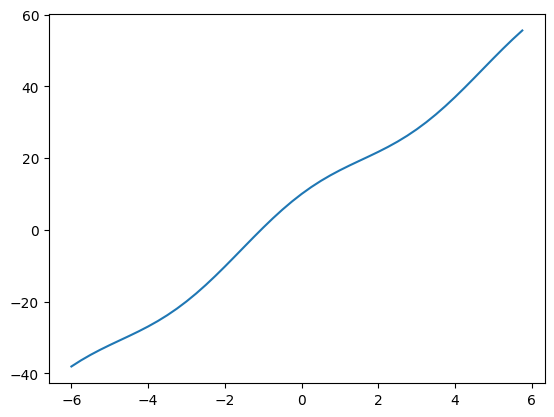

In [5]:
plt.plot(xs,dys1)

In [6]:
#for multivariate
def l(a,b,c):
    return a*b + c

h = 0.0001
a = 3
b = -4
c = 2.4

#wrt a
d_a = (l(a+h,b,c)-l(a,b,c))/h
#similarly
d_b = (l(a,b+h,c)-l(a,b,c))/h
d_c = (l(a,b,c+h)-l(a,b,c))/h

print(f"{l(a,b,c)} {d_a} {d_b} {d_c}")

-9.6 -4.000000000008441 3.000000000010772 0.9999999999976694


In [16]:
class Value:
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
    def __repr__(self):
        return f"Value(data:{self.data})"
    def __add__(self,other):
        return Value(self.data+other.data, (self, other), '+')
    def __mul__(self,other):
        return Value(self.data*other.data, (self,other), '*')
    def tanh(self):
        x = self.data
        return Value( (math.exp(2*x) - 1)/(math.exp(2*x) + 1),(self,) ,'tanh')

h = 0.0001
a = Value(3); a.label='a'
b = Value(-4) ; b.label='b'
c = Value(2.4) ; c.label='c'
d = a*b ; d.label='d'
L = d + c; L.label='L'
print(L)

Value(data:-9.6)


### Insights from Manual Backpropagation

1. Use chain rule to determine the gradients(meaning how those variables affect the loss function).\
   so calculate dl/d{x_i}
2. Altering the variables in the direction of the respective gradients increases the loss function (optimization)\
   i.e., x_i = x_i + (d_xi)*f ; where f is some factor 

In [8]:
#Yes I copy pasted this, I don't want to learn a new library :')

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot



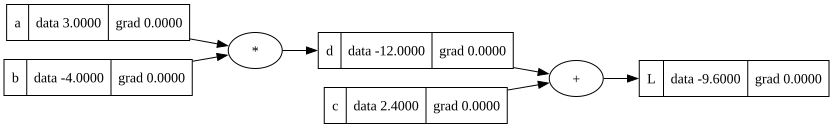

In [9]:
draw_dot(L)
#I didnt set the manual gradients

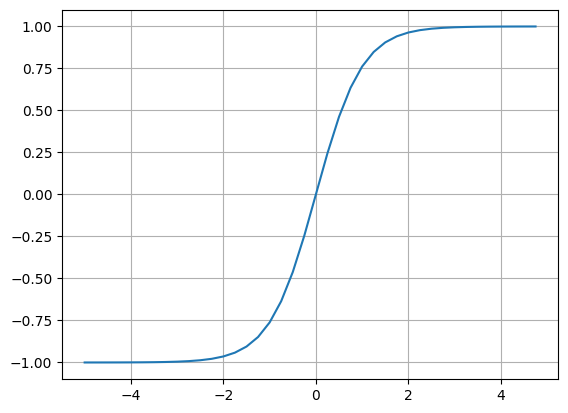

In [10]:
#activation function tanh(x)
plt.plot(np.arange(-5,5,0.25), np.tanh(np.arange(-5,5,0.25)))
plt.grid()

In [34]:
#inputs
x1 = Value(4, label='x1')
x2 = Value(2.3, label='x2')

#weights
w1 = Value(-1.2, label='w1')
w2 = Value(0, label='w2')

#bias
b = Value(3, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

xw = x1w1 + x2w2; xw.label =  'x1*w1 + x2*w2'
n = xw + b; n.label = 'n'
o = n.tanh() ; o.label = 'o'

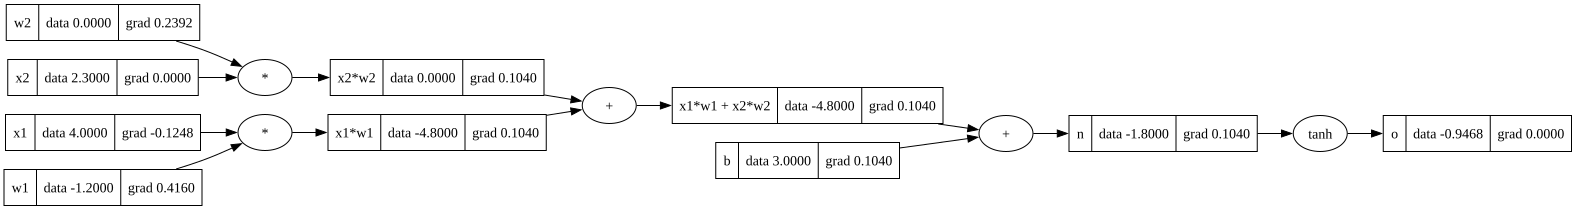

In [41]:
draw_dot(o)

In [40]:
## Manual gradient assignment
#do/dn = 1 - o**2 ( d(tanh(x)) = 1- tanh^2(x))
#x.grad = do/dx (partial)

n.grad = 0.104
xw.grad = n.grad
b.grad = n.grad

x2w2.grad = xw.grad
x1w1.grad = xw.grad

w2.grad = x2w2.grad * x2.data
x2.grad = x2w2.grad * w2.data
w1.grad = x1w1.grad * x1.data
x1.grad = x1w1.grad * w1.data

In [31]:
1 - o.data**2

0.10355837403815227